# Классификация заемщиков линейными моделями, part 2

## курс "Машинное обучение 1", программа AIMasters, 2024

## Студент: Загайнов Никита Владиславович

Эксперименты будем проводить на [датасете](https://www.kaggle.com/competitions/home-credit-default-risk/overview) по классификации заемщиков на плохих (target = 1: клиент с "payment difficulties") и хороших (target = 0: все остальные). 

Описание колонок находится в файле `description.csv`.

Для начала мы за вас считаем данные и поделим на обучение и тест.

Код в чтение, разбиение менять не нужно.

Выполняя задания, не забывайте про [устав](https://t.me/c/2206639786/270/271).

In [1]:
# не меняем код
import pandas as pd
import numpy as np


pd.options.display.max_columns = 100
pd.options.display.max_rows = 150


data = pd.read_csv("application_train.csv")
data.columns = ["sk_id_curr", "target"] + list(data.columns[2:])
data.head(3)

,sk_id_curr,target,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
# не меняем код
test_idx = data.sk_id_curr % 10 >= 7
data_dict = dict()
data_dict["tst"] = data.loc[test_idx].reset_index(drop=True)
data_dict["tr"] = data.loc[~test_idx].reset_index(drop=True)

for key, df in data_dict.items():
    print(key, "shape:", df.shape)

tst shape: (92221, 122)
tr shape: (215290, 122)


## Пайплайны (5 баллов)

Вам предлагается реализовать свой пайплайн предобработки данных + обучение линейной модели.

Примеры использования sklearn [pipeline](https://scikit-learn.org/1.5/modules/generated/sklearn.pipeline.Pipeline.html) можете найти в ноутбуке с семинара по предобработке.

Можно использовать все, что есть в https://scikit-learn.org/1.5/modules/preprocessing.html + оборачивать все в кастомные трансформеры (про них ниже).

На выходе у вас должна стоять линейная модель.

Любой код ниже **можно** менять.

In [3]:
from matplotlib import pyplot as plt
import seaborn as sns
import random

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score

import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

In [4]:
num_features = (
    data.select_dtypes(np.number).drop(columns=["target", "sk_id_curr"]).columns
)
num_features

Index(['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
       'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=104)

In [5]:
cat_features = data.select_dtypes("object").columns
cat_features, len(cat_features)

(Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
        'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
        'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
        'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
        'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
       dtype='object'),
 16)

In [6]:
num_transformer = Pipeline(
    [
        ("imp_mean", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)
cat_transformer = Pipeline(
    steps=[
        ("imput_missing", SimpleImputer(strategy="constant", fill_value="missing")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [7]:
ct = ColumnTransformer(
    transformers=[
        ("num", num_transformer, list(num_features)),
        ("cat", cat_transformer, list(cat_features)),
    ]
)

In [8]:
pipeline = Pipeline(
    [
        ("ct", ct),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

In [9]:
pipeline.fit(
    data_dict["tr"].drop(columns=["target", "sk_id_curr"]), data_dict["tr"].target
)

roc_auc_score(
    data_dict["tst"].target,
    pipeline.predict_proba(data_dict["tst"].drop(columns=["target", "sk_id_curr"]))[
        :, 1
    ],
)

0.7465453445894231

### Кастомные трансформеры

В этом пункте вам нужно добавить один любой кастомный трансформер данных. (можно больше, минимум 1)

Примеры кастомных трансформеров можно найти
- в семинаре по предобработке
- https://www.andrewvillazon.com/custom-scikit-learn-transformers/
- https://medium.com/@pgshanding/creating-custom-transformers-in-python-and-scikit-learn-10767487017e
- в интернете :)

Варианты трансформеров
- генерация новых признаков, примеры новых признаков можно найти в соревновании с kaggle, откуда был взят датасет https://www.kaggle.com/competitions/home-credit-default-risk/code?competitionId=9120&sortBy=voteCount&excludeNonAccessedDatasources=true, т.е. ваш трансформер принимает на вход pd.DataFrame и добавляет новые колонки с признаками
- категорийные энкодеры, которые не реализованы в sklearn, можно взять готовые реализации и обернуть их в свой трансформер. Примеры категорийных энкодеров - https://www.kaggle.com/code/subinium/11-categorical-encoders-and-benchmark, примеры реализаций - https://contrib.scikit-learn.org/category_encoders/ (если не требуется дополнительный код для использования в вашем пайплайне, можете использовать as is)
- замена пропусков от SimpleImputer с добавлением нового признака, что был пропуск 
- эмбединг текста из одного/нескольких признаков
- любой другой ваш вариант, который дает результат

Не забудьте добавить комментарий, что делает ваш трансформер.

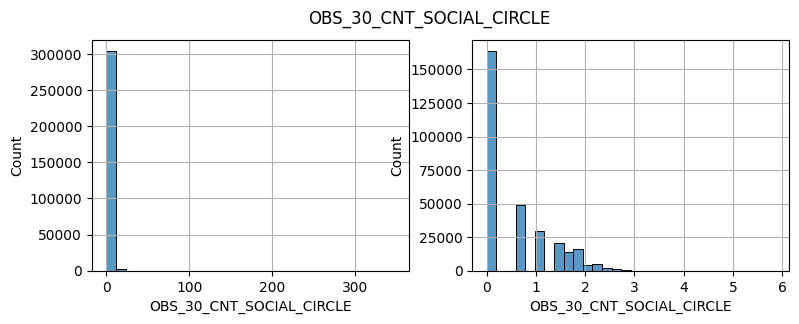

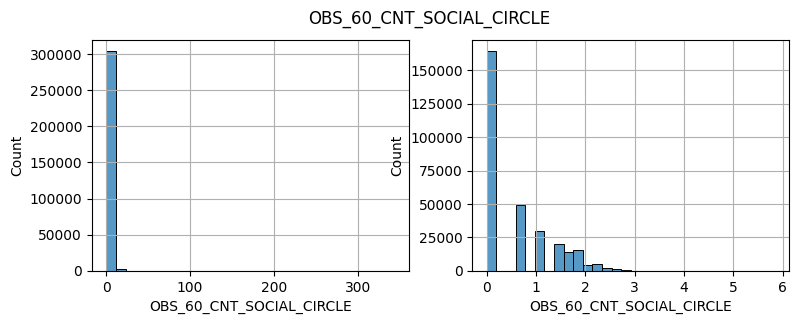

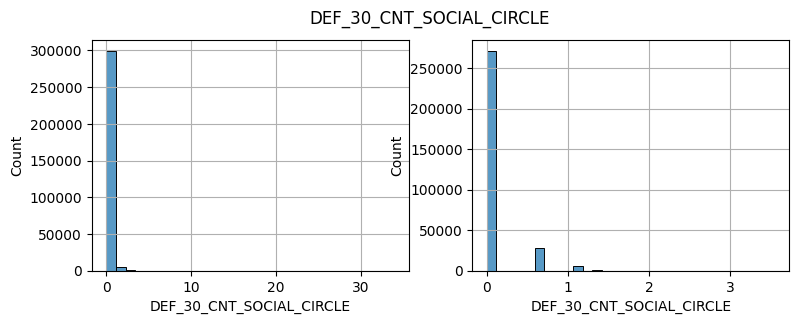

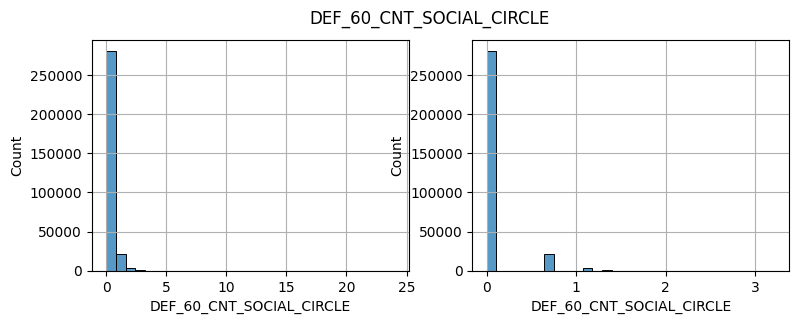

In [10]:
# Распределения некоторых фичей имеют тяжелые хвосты. 
# Попробуем прологарифмировать их в будущем
def plot_dist_and_log_dist(df: pd.DataFrame, feature: str):
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    sns.histplot(df[feature], bins=30, ax=axes[0])
    sns.histplot(np.log1p(df[feature]), bins=30, ax=axes[1])
    plt.suptitle(feature)
    axes[0].grid()
    axes[1].grid()
    plt.show()

log_features = [
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
]

for feature in log_features:
    plot_dist_and_log_dist(data, feature)

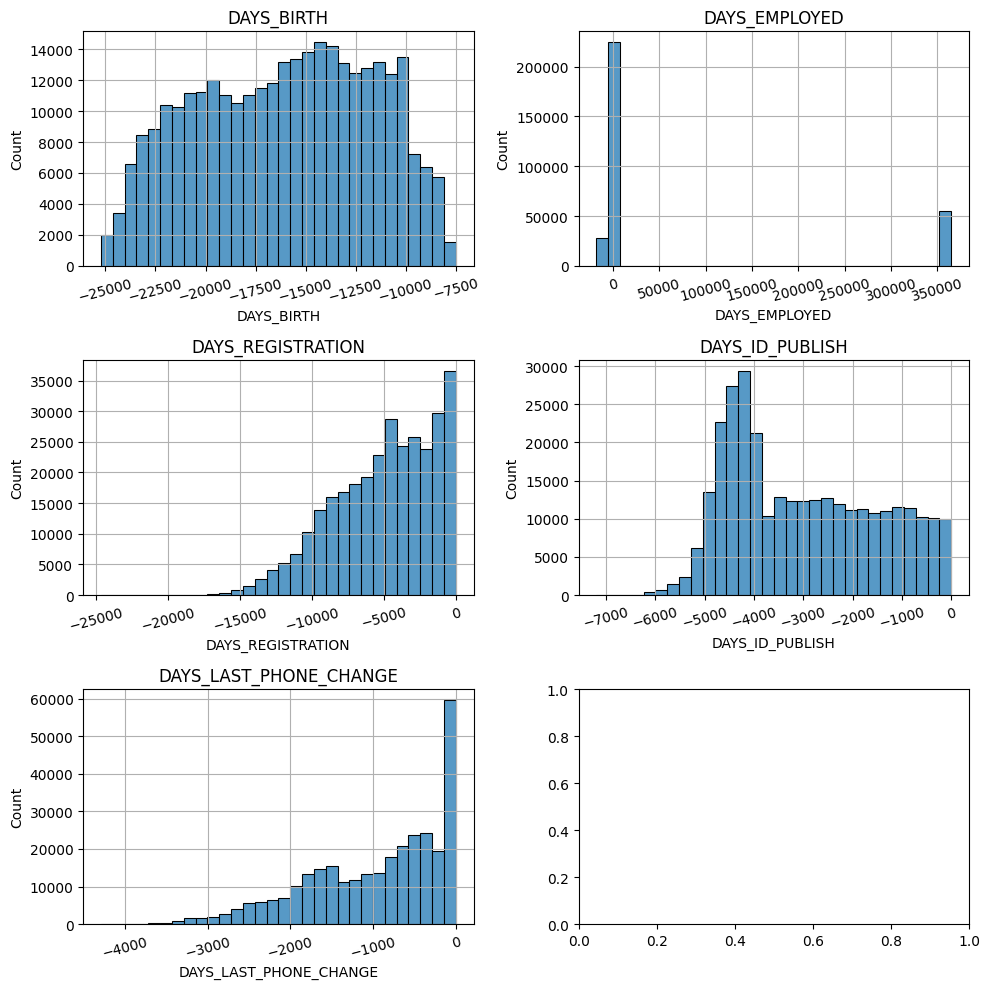

In [11]:
# Фичи с днями имеют отрицательные значения
# Для удобства восприятия преобразуем их в года
# А затем примени bucketing
def plot_dist(df: pd.DataFrame, feature: str, ax: plt.Axes):
    sns.histplot(df[feature], bins=30, ax=ax)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=15)
    ax.grid()

day_features = [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()
for i, feature in enumerate(day_features):
    plot_dist(data, feature, axes[i])
plt.tight_layout()

In [12]:
# Заменим неестественные значения на np.nan
class HeuristicImput(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame):
        df = X.copy()
        df.loc[:, "DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
        return df


# Переводит дни в года для более удобного диапазона данных
class DiscretizeDays(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X: pd.DataFrame):
        df = X.copy()
        df.loc[:, "YEARS_BIRTH"] = np.floor(-df["DAYS_BIRTH"] / 365)
        df.loc[:, "YEARS_EMPLOYED"] = np.floor(-df["DAYS_EMPLOYED"] / 365)
        df.loc[:, "YEARS_REGISTRATION"] = np.floor(-df["DAYS_REGISTRATION"] / 365)
        df.loc[:, "YEARS_ID_PUBLISH"] = np.floor(-df["DAYS_ID_PUBLISH"] / 365)
        df.loc[:, "YEARS_LAST_PHONE_CHANGE"] = np.floor(
            -df["DAYS_LAST_PHONE_CHANGE"] / 365
        )

        return df


# Делим фичи с годами на бакеты
class BucketYears(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def _map(self, value):
        thresholds = [22, 27, 32, 36, 42, 60, 80, 100]

        for i, threshold in enumerate(thresholds):
            if value < threshold:
                return i + 1

        return 0

    def transform(self, X: pd.DataFrame):
        df = X.copy()
        cols_to_bucket = [
            "YEARS_BIRTH",
            "YEARS_EMPLOYED",
            "YEARS_REGISTRATION",
            "YEARS_ID_PUBLISH",
            "YEARS_LAST_PHONE_CHANGE",
        ]
        for col in cols_to_bucket:
            df.loc[:, f"BUCKET_{col}"] = df[col].map(self._map)

        return df


# Этот трансформер сделан добавляет несколько потенциально полезных фичей
# Идея взята отсюда:
# https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction
class AddFeatures(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        # Фичи, которые взяты с решения на Kaggle
        df.loc[:, "CREDIT_INCOME_PERCENT"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
        df.loc[:, "ANNUITY_INCOME_PERCENT"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
        df.loc[:, "CREDIT_TERM"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

        # Фичи, которые я придумал
        # в знаменателе добавляем что-то, чтобы избежать деления на 0
        df.loc[:, "YEARS_EMPLOYED_PERCENT"] = df["YEARS_EMPLOYED"] / df["YEARS_BIRTH"]
        df.loc[:, "CHILDREN_RATIO"] = df["CNT_CHILDREN"] / (df["CNT_FAM_MEMBERS"] + 0.5)
        df.loc[:, "INCOME_PER_CHILD"] = df["AMT_INCOME_TOTAL"] / (
            0.5 + df["CNT_CHILDREN"]
        )
        df.loc[:, "INCOME_PER_FAM_MEMBER"] = df["AMT_INCOME_TOTAL"] / (
            df["CNT_FAM_MEMBERS"] + 0.5
        )
        df.loc[:, "INCOME_PER_CHILD"] = df["AMT_INCOME_TOTAL"] / (
            df["CNT_CHILDREN"] + 0.5
        )
        df.loc[:, "INCOME_CREDIT_PERC"] = df["AMT_INCOME_TOTAL"] / (
            df["AMT_CREDIT"] + 0.5
        )
        df.loc[:, "CREDIT_INCOME_PERC"] = df["AMT_CREDIT"] / (
            df["AMT_INCOME_TOTAL"] + 0.5
        )

        return df


# Некоторые фичи имеют тяжелые хвосты
# чтобы увеличить стабильность модели, прологарифмируем их
class AdaptiveLogTransform(BaseEstimator, TransformerMixin):
    def __init__(self, var_threshold: float = 4.5):
        self.z_value = var_threshold

    def fit(self, X: pd.DataFrame, y=None):
        num_cols = X.select_dtypes(np.number).columns
        self.log_cols = []

        # Если встречаются значения, выходящие за z_value * var,
        # то логарифмируем
        for col in num_cols:
            if X[col].min() < 0:
                continue
            if X[col].max() >= X[col].mean() + self.z_value * X[col].var():
                self.log_cols.append(col)
        return self

    def transform(self, X: pd.DataFrame):
        df = X.copy()
        for col in self.log_cols:
            df.loc[:, col] = np.log1p(df[col])

        return df


# По-разному обрабатываем числовые и категориальные фичи
# Числовые фичи: заполняем пропуски средним, стандартизируем
# Категориальные фичи: заполняем пропуски константой, кодируем OHE
class AdaptiveTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_imput_strategy: str = "constant"):
        self.scaler = StandardScaler()
        self.mean_imputer = SimpleImputer(strategy="mean")
        if cat_imput_strategy == "constant":
            self.nan_imputer = SimpleImputer(
                strategy=cat_imput_strategy, fill_value="missing"
            )
        else:
            self.nan_imputer = SimpleImputer(strategy=cat_imput_strategy)
        self.one_hot_encoder = OneHotEncoder(handle_unknown="ignore")

    def fit(self, X: pd.DataFrame, y=None):
        self.num_features = num_features = X.select_dtypes(np.number).columns.tolist()
        self.cat_features = cat_features = X.select_dtypes("object").columns.tolist()

        self.ct = ColumnTransformer(
            transformers=[
                ("num", make_pipeline(self.mean_imputer, self.scaler), num_features),
                (
                    "cat",
                    make_pipeline(self.nan_imputer, self.one_hot_encoder),
                    cat_features,
                ),
            ]
        )
        self.ct.fit(X)

        return self

    def transform(self, X: pd.DataFrame):
        df = X.copy()
        df = self.ct.transform(df)
        df = pd.DataFrame(df, columns=self.ct.get_feature_names_out())
        return df


# Позволяет добавить полиномиальные фичи
# Из заданного сабсета фичей.
# Идея взята отсюда:
# https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction/notebook
class SubsetPolynomialFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, degree: int = 2, cols: list[str] = []):
        self.transformer = PolynomialFeatures(degree=degree)
        self.degree = degree
        self.cols = cols

    def fit(self, X: pd.DataFrame, y=None):
        self.transformer.fit(X[self.cols])
        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()
        new_arr = self.transformer.transform(X[self.cols])
        X = np.hstack([X.to_numpy(), new_arr])
        return X


# PolynomialFeatures может занять слишком много памяти и времени
# Этот трансформер представляет менее затратный аналог
class RandomizedPolynomialFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, degree: int = 2, n_features: int = 10):
        self.degree = degree
        self.n_features = n_features
        self.indices = set()

    def fit(self, X, y=None):
        self.indices = set()
        for _ in range(self.n_features):
            indices = tuple(np.random.choice(X.shape[1], self.degree).tolist())
            while indices in self.indices:
                indices = tuple(np.random.choice(X.shape[1], self.degree).tolist())

            self.indices.add(indices)

        return self

    def transform(self, X):
        X = X.copy()

        new_arr = np.empty((X.shape[0], len(self.indices)))
        for i, indices in enumerate(self.indices):
            new_arr[:, i] = np.prod(X[:, indices], axis=1)

        X = np.hstack([X, new_arr])

        return X

In [13]:
preprocessing_pipeline = Pipeline(
    [
        ("heur_imput", HeuristicImput()),
        ("discretize_days", DiscretizeDays()),
        ("bucket_years", BucketYears()),
        (
            "log_transformer",
            AdaptiveLogTransform(var_threshold=4.0),
        ),
    ]
)

feature_engineering_pipeline = Pipeline(
    [
        ("add_features", AddFeatures()),
    ]
)

adaptive_transformer = AdaptiveTransformer(
    "most_frequent",
)
heuristic_poly_features = SubsetPolynomialFeatures(
    degree=2,
    cols=[
        "num__EXT_SOURCE_1",
        "num__EXT_SOURCE_2",
        "num__EXT_SOURCE_3",
        "num__YEARS_BIRTH",
    ],
)
rand_poly_features = RandomizedPolynomialFeatures(
    n_features=100,
    degree=3,
)


full_pipeline = Pipeline(
    [
        ("preprocessing", preprocessing_pipeline),
        ("feature_engineering", feature_engineering_pipeline),
        ("adaptive_transformer", adaptive_transformer),
        ("heuristic_poly_features", heuristic_poly_features),
        ("rand_poly_features", rand_poly_features),
        ("linear_model", LogisticRegression(max_iter=1000, C=0.01, tol=1e-6)),
    ]
)

Выбейте на тесте больше `0.752` [roc_auc_score](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.roc_auc_score.html).
Для поиска лучшей модели можно использовать:
- optuna
- [GridSearchCV](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.GridSearchCV.html)
- свои наблюдения и интуицию

In [14]:
X_train = data_dict["tr"].drop(columns=["target", "sk_id_curr"])
y_train = data_dict["tr"].target
X_test = data_dict["tst"].drop(columns=["target", "sk_id_curr"])
y_test = data_dict["tst"].target

In [15]:
full_pipeline.fit(X_train, y_train)
preds = full_pipeline.predict_proba(X_test)[:, 1]

In [16]:
roc_auc_score(y_test, preds)

0.752028567443757

### Бонусы (до +5 баллов)

За вашу работу можно получить до 5 бонусных баллов <br>
За какие заслуги можно получить бонус:
- скор на тесте значительно больше 0.752 (будет сравниваться с другими работами студентов)
- интересные реализации кастомных трансформеров
- интересные находки в данных, которые увеличили вам скор. Опишите, что вы нашли и как это помогло увеличить скор.
- см. пункт "Хорошие работы" в [уставе](https://t.me/c/2206639786/270/271) 

In [17]:
# ваш код